### Data Cleaning

This notebook focuses on cleaning and preparing Amazon reviews data for sentiment analysis using PySpark. It loads the dataset, handles missing values, and creates new features to better capture the sentiment in the reviews

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan, isnull, mean, stddev, min, max, length, avg, expr, when, desc, concat, lit, coalesce, year, month, dayofweek
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DateType
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import Window
import numpy as np
from pyspark.ml.feature import OneHotEncoder, StringIndexer, Tokenizer, StopWordsRemover, HashingTF
from pyspark.ml import Pipeline

In [2]:
spark = SparkSession.builder \
    .appName("Amazon Reviews Data Cleaning") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "6g") \
    .config("spark.executor.cores", "1") \
    .config("spark.default.parallelism", "16") \
    .config("spark.sql.shuffle.partitions", "16") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/03/29 19:14:41 INFO SparkEnv: Registering MapOutputTracker
25/03/29 19:14:41 INFO SparkEnv: Registering BlockManagerMaster
25/03/29 19:14:41 INFO SparkEnv: Registering BlockManagerMasterHeartbeat
25/03/29 19:14:41 INFO SparkEnv: Registering OutputCommitCoordinator


In [3]:
reviews_df = spark.read.parquet("gs://final-project-bucket-amazon/processed/all_reviews.parquet")
print(f"Loaded {reviews_df.count()} reviews from parquet")

Loaded 18118476 reviews from parquet


In [4]:
# View first few rows of the dataset
reviews_df.show(2)

+-----------+-----------+--------------+----------+--------------+--------------------+----------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+------------------+
|marketplace|customer_id|     review_id|product_id|product_parent|       product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|     review_headline|         review_body|review_date|     helpful_ratio|
+-----------+-----------+--------------+----------+--------------+--------------------+----------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+------------------+
|         US|   51187967|R3UE1NIEC0LNPD|078942052X|     428637498|The Amazing Pull-...|           Books|          3|           40|         42|   N|                N|More of a Poster ...|This is not a boo...| 1999-12-11|0.9523809523809523|
|         US|   50547216| RPEX7APLGS3MM|0553

### Addressing null values

In [5]:
# Check for null values in each column
print("Null values by column:")
null_counts = reviews_df.select([count(when(col(c).isNull(), c)).alias(c) for c in reviews_df.columns])
null_counts.show()

Null values by column:


+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+-------------+
|marketplace|customer_id|review_id|product_id|product_parent|product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|review_headline|review_body|review_date|helpful_ratio|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------+-----------+-----------+-------------+
|          0|          0|        0|         0|             0|            0|               0|          0|            0|          0|   0|                0|              0|          0|          0|      9729685|
+-----------+-----------+---------+----------+--------------+-------------+----------------+-----------+-------------+-----------+----+-----------------+---------------

In [6]:
# Filter for rows with null helpful_ratio
null_helpful_ratio_rows = reviews_df.filter(col("helpful_ratio").isNull())

# Show a few examples
print(f"Showing 5 examples of rows with null helpful_ratio (out of {null_helpful_ratio_rows.count()}):")
null_helpful_ratio_rows.select("star_rating", "helpful_votes", "total_votes", "helpful_ratio").show(5)

# Check if these null values correspond to zero total_votes
zero_votes_count = reviews_df.filter(col("total_votes") == 0).count()
print(f"\nNumber of rows with total_votes = 0: {zero_votes_count}")

# Confirm if all null helpful_ratio rows have zero total_votes
null_ratio_with_zero_votes = reviews_df.filter(
    (col("helpful_ratio").isNull()) & (col("total_votes") == 0)
).count()

print(f"Number of rows with null helpful_ratio AND zero total_votes: {null_ratio_with_zero_votes}")
print(f"This represents {null_ratio_with_zero_votes/null_helpful_ratio_rows.count()*100:.2f}% of all null helpful_ratio rows")

Showing 5 examples of rows with null helpful_ratio (out of 9729685):
+-----------+-------------+-----------+-------------+
|star_rating|helpful_votes|total_votes|helpful_ratio|
+-----------+-------------+-----------+-------------+
|          5|            0|          0|         NULL|
|          5|            0|          0|         NULL|
|          5|            0|          0|         NULL|
|          4|            0|          0|         NULL|
|          5|            0|          0|         NULL|
+-----------+-------------+-----------+-------------+
only showing top 5 rows




Number of rows with total_votes = 0: 9729685


Number of rows with null helpful_ratio AND zero total_votes: 9729685


This represents 100.00% of all null helpful_ratio rows


In [7]:
# Fill null values in helpful_ratio with 0
reviews_df = reviews_df.fillna({"helpful_ratio": 0})

In [8]:
reviews_df.select("helpful_votes","total_votes").show(5)

+-------------+-----------+
|helpful_votes|total_votes|
+-------------+-----------+
|           40|         42|
|           17|         21|
|            8|         10|
|            6|          7|
|            7|          8|
+-------------+-----------+
only showing top 5 rows



In [9]:
reviews_df = reviews_df.withColumn(
    "has_votes", 
    when(col("total_votes") > 0, 1).otherwise(0)
)

We found that helpful_ratio is null only when a review has zero votes. To handle this, we filled those null values with 0 and also created a binary feature called has_votes to indicate whether a review received any votes. This approach avoids complications from missing data while keeping useful information for the model.

In [10]:
# Check reviews with missing or very short content
reviews_df = reviews_df.withColumn("review_length", length("review_body"))

problematic_reviews = reviews_df.filter(
    (length(col("review_body")) < 5) | 
    (col("product_id").isNull()) | 
    (col("star_rating").isNull())
)

# Show a few examples
print(f"Number of problematic reviews found: {problematic_reviews.count()}")
print("\nSample of problematic reviews:")
problematic_reviews.select("product_id", "star_rating", "review_body", "review_length").show(5, truncate=False)

# Show distribution of star ratings for short reviews
print("\nStar rating distribution for very short reviews:")
reviews_df.filter(length(col("review_body")) < 5).groupBy("star_rating").count().orderBy("star_rating").show()

# Show some examples of short reviews by rating
print("\nSamples of short reviews by rating:")
for rating in range(1, 6):
    print(f"\nStar rating: {rating}")
    reviews_df.filter((length(col("review_body")) < 5) & (col("star_rating") == rating)) \
        .select("product_category", "review_body", "review_headline") \
        .show(2, truncate=False)

Number of problematic reviews found: 144412

Sample of problematic reviews:


+----------+-----------+-----------+-------------+
|product_id|star_rating|review_body|review_length|
+----------+-----------+-----------+-------------+
|0967017009|5          |BROO       |4            |
|0140062866|5          |1          |1            |
|1560103620|5          |Coo        |3            |
|0312215584|5          |funn       |4            |
|0375503323|5          |Goo        |3            |
+----------+-----------+-----------+-------------+
only showing top 5 rows


Star rating distribution for very short reviews:


+-----------+-----+
|star_rating|count|
+-----------+-----+
|          1| 3860|
|          2| 2405|
|          3|13457|
|          4|31204|
|          5|93486|
+-----------+-----+


Samples of short reviews by rating:

Star rating: 1


+----------------+-----------+-------------------------------+
|product_category|review_body|review_headline                |
+----------------+-----------+-------------------------------+
|Books           |HUH        |Re: Reader from cincinnati ohio|
|Books           |COol       |ok                             |
+----------------+-----------+-------------------------------+
only showing top 2 rows


Star rating: 2


+----------------+-----------+---------------+
|product_category|review_body|review_headline|
+----------------+-----------+---------------+
|Books           |c          |c              |
|Books           |d          |i              |
+----------------+-----------+---------------+
only showing top 2 rows


Star rating: 3


+----------------+-----------+-----------------------+
|product_category|review_body|review_headline        |
+----------------+-----------+-----------------------+
|Books           |SUPI       |A ver sophisicated book|
|Books           |o          |ok                     |
+----------------+-----------+-----------------------+
only showing top 2 rows


Star rating: 4


+----------------+-----------+---------------------------------------------------------+
|product_category|review_body|review_headline                                          |
+----------------+-----------+---------------------------------------------------------+
|Books           |Non        |Was very intersting for the way of changing of my person.|
|Books           |goo        |good                                                     |
+----------------+-----------+---------------------------------------------------------+
only showing top 2 rows


Star rating: 5


+----------------+-----------+---------------+
|product_category|review_body|review_headline|
+----------------+-----------+---------------+
|Books           |BROO       |GG ROCK        |
|Books           |1          |1              |
+----------------+-----------+---------------+
only showing top 2 rows



From the above output, we can see that some short reviews had meaningful information in their headlines. So we combined the review headline and review body to create a more comprehensive text field. This approach helps retain valuable sentiment data that would otherwise be lost if we only filtered based on the review body length.

In [11]:
# Combine headline and body for all reviews
reviews_df = reviews_df.withColumn(
    "combined_review_text",
    concat(
        coalesce(col("review_headline"), lit("")), 
        lit(" "), 
        coalesce(col("review_body"), lit(""))
    )
)

# Add length of combined text as a feature
reviews_df = reviews_df.withColumn(
    "combined_text_length",
    length(col("combined_review_text"))
)

# Flag reviews with sufficient content (you can adjust the threshold as needed)
reviews_df = reviews_df.withColumn(
    "has_meaningful_content",
    when(col("combined_text_length") >= 10, 1).otherwise(0)
)

# Check how many reviews still have insufficient content
insufficient_reviews = reviews_df.filter(col("has_meaningful_content") == 0)
print(f"Reviews with insufficient combined text: {insufficient_reviews.count()}")

# Show some examples of reviews with short combined text
print("\nSamples of reviews with short combined content:")
insufficient_reviews.select(
    "star_rating", 
    "review_headline", 
    "review_body", 
    "combined_review_text", 
    "combined_text_length"
).show(5, truncate=False)

# Examine reviews that are just above our threshold (10-12 characters)
# This helps confirm if our threshold is appropriate
borderline_reviews = reviews_df.filter((col("combined_text_length") >= 10) & (col("combined_text_length") <= 12))
print(f"\nBorderline reviews (10-12 chars) count: {borderline_reviews.count()}")
print("\nSamples of borderline reviews we're keeping:")
borderline_reviews.select(
    "star_rating", 
    "review_headline", 
    "review_body", 
    "combined_review_text", 
    "combined_text_length"
).orderBy(col("combined_text_length")).show(10, truncate=False)

# Now filter to create our clean dataset
clean_reviews_df = reviews_df.filter(col("has_meaningful_content") == 1)
print(f"\nOriginal review count: {reviews_df.count()}")
print(f"After filtering insufficient content: {clean_reviews_df.count()}")
print(f"Removed {reviews_df.count() - clean_reviews_df.count()} reviews ({((reviews_df.count() - clean_reviews_df.count()) / reviews_df.count()) * 100:.4f}% of total)")

Reviews with insufficient combined text: 7626

Samples of reviews with short combined content:


+-----------+---------------+-----------+--------------------+--------------------+
|star_rating|review_headline|review_body|combined_review_text|combined_text_length|
+-----------+---------------+-----------+--------------------+--------------------+
|5          |1              |1          |1 1                 |3                   |
|5          |Cool           |Coo        |Cool Coo            |8                   |
|5          |ljk            |io         |ljk io              |6                   |
|5          |xx             |xxxx       |xx xxxx             |7                   |
|5          |asdsa          |as         |asdsa as            |8                   |
+-----------+---------------+-----------+--------------------+--------------------+
only showing top 5 rows




Borderline reviews (10-12 chars) count: 13995

Samples of borderline reviews we're keeping:


+-----------+---------------+-----------+--------------------+--------------------+
|star_rating|review_headline|review_body|combined_review_text|combined_text_length|
+-----------+---------------+-----------+--------------------+--------------------+
|5          |onzero         |100        |onzero 100          |10                  |
|5          |nice           |great      |nice great          |10                  |
|2          |Two Stars      |           |Two Stars           |10                  |
|1          |Sorry          |JUNK       |Sorry JUNK          |10                  |
|1          |One Star       |👎         |One Star 👎         |10                  |
|5          |:)             |Thanks!    |:) Thanks!          |10                  |
|4          |Nice.          |Nice       |Nice. Nice          |10                  |
|1          |One Star       |😷         |One Star 😷         |10                  |
|5          |☺              |Nice man   |☺ Nice man          |10                


Original review count: 18118476


After filtering insufficient content: 18110850


Removed 7626 reviews (0.0421% of total)


Looking at the borderline reviews we're keeping (those with 10-12 characters), we can see they contain brief but meaningful sentiment information like "TRASH Junk" or "nice yummy". 

By combining review headlines with bodies and filtering out only the extremely short reviews (< 10 characters), we've removed potential noise while preserving over 99.95% of our data. 

This cleaning approach helps our sentiment analysis model focus on meaningful content

Additionally, we created a binary has_votes flag and imputed null values in the helpful_ratio column. This approach preserves the information about whether a review received any votes at all. By using this flag as a feature in our model, we can capture the relationship between vote presence and sentiment without introducing artificial values that might distort the data patterns

### Addressing non-numerical features

In [12]:
clean_reviews_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- helpful_ratio: double (nullable = false)
 |-- has_votes: integer (nullable = false)
 |-- review_length: integer (nullable = true)
 |-- combined_review_text: string (nullable = false)
 |-- combined_text_length: integer (nullable = false)
 |-- has_meaningful_content: integer (nullable = false)



* marketplace, customer_id, review_id, product_id, product_parent: These are primarily identification fields that won't contribute directly to sentiment prediction. So we will keep them for reference but not as model features

* Since our focus is on reviews themselves, product_title can be omitted from features. review_headline and review_body are already addressed by creating combined_review_text, which will be our primary text feature.

* product_category is an important categorical feature that should be one-hot encoded or label encoded. vine and verified_purchase can be converted to binary (0/1)

* review_date can be transformed into useful features like Year of review or Month of review

In [13]:
# Categorical encoding
# Convert vine and verified_purchase to binary
clean_reviews_df = clean_reviews_df.withColumn(
    "vine_binary", 
    when(col("vine") == "Y", 1).otherwise(0)
)

clean_reviews_df = clean_reviews_df.withColumn(
    "verified_purchase_binary", 
    when(col("verified_purchase") == "Y", 1).otherwise(0)
)

In [14]:
# First convert string to indices
category_indexer = StringIndexer(
    inputCol="product_category", 
    outputCol="product_category_index"
)

# Then one-hot encode
category_encoder = OneHotEncoder(
    inputCol="product_category_index", 
    outputCol="product_category_vec"
)

# Create and apply category encoding pipeline
category_pipeline = Pipeline(stages=[category_indexer, category_encoder])
category_pipeline_model = category_pipeline.fit(clean_reviews_df)
clean_reviews_df = category_pipeline_model.transform(clean_reviews_df)

In [15]:
# Date feature engineering
clean_reviews_df = clean_reviews_df.withColumn("review_year", year("review_date"))
clean_reviews_df = clean_reviews_df.withColumn("review_month", month("review_date"))
clean_reviews_df = clean_reviews_df.withColumn("review_dayofweek", dayofweek("review_date"))

In [16]:
# Define the text processing pipeline
tokenizer = Tokenizer(inputCol="combined_review_text", outputCol="words")
remover = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashingTF = HashingTF(inputCol="filtered_words", outputCol="features", numFeatures=10000)

pipeline = Pipeline(stages=[tokenizer, remover, hashingTF])

# Repartition to improve parallelism (adjust based on your cluster)
clean_reviews_df = clean_reviews_df.repartition(16)

# Fit pipeline once and transform everything
pipeline_model = pipeline.fit(clean_reviews_df)
processed_df = pipeline_model.transform(clean_reviews_df)

In [17]:
processed_df.printSchema()

root
 |-- marketplace: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- product_parent: string (nullable = true)
 |-- product_title: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- star_rating: integer (nullable = true)
 |-- helpful_votes: integer (nullable = true)
 |-- total_votes: integer (nullable = true)
 |-- vine: string (nullable = true)
 |-- verified_purchase: string (nullable = true)
 |-- review_headline: string (nullable = true)
 |-- review_body: string (nullable = true)
 |-- review_date: date (nullable = true)
 |-- helpful_ratio: double (nullable = false)
 |-- has_votes: integer (nullable = false)
 |-- review_length: integer (nullable = true)
 |-- combined_review_text: string (nullable = false)
 |-- combined_text_length: integer (nullable = false)
 |-- has_meaningful_content: integer (nullable = false)
 |-- vine_binary: integer (nullable = f

In [18]:
# Create a new column called 'label'
processed_df = processed_df.withColumn(
    "label",
    when(col("star_rating") <= 3, 0)
    .otherwise(1)
)

In [19]:
processed_df.show(1)

25/03/29 19:26:12 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-----------+-----------+--------------+----------+--------------+-------------------+----------------+-----------+-------------+-----------+----+-----------------+--------------------+--------------------+-----------+-------------+---------+-------------+--------------------+--------------------+----------------------+-----------+------------------------+----------------------+--------------------+-----------+------------+----------------+--------------------+--------------------+--------------------+-----+
|marketplace|customer_id|     review_id|product_id|product_parent|      product_title|product_category|star_rating|helpful_votes|total_votes|vine|verified_purchase|     review_headline|         review_body|review_date|helpful_ratio|has_votes|review_length|combined_review_text|combined_text_length|has_meaningful_content|vine_binary|verified_purchase_binary|product_category_index|product_category_vec|review_year|review_month|review_dayofweek|               words|      filtered_words|

In [20]:
# Save the full processed result
processed_df.coalesce(8).write.mode("overwrite").parquet("gs://final-project-bucket-amazon/processed/all_reviews_processed.parquet")

In [21]:
processed_df.columns

['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date',
 'helpful_ratio',
 'has_votes',
 'review_length',
 'combined_review_text',
 'combined_text_length',
 'has_meaningful_content',
 'vine_binary',
 'verified_purchase_binary',
 'product_category_index',
 'product_category_vec',
 'review_year',
 'review_month',
 'review_dayofweek',
 'words',
 'filtered_words',
 'features',
 'label']

In [22]:
processed_df.groupBy("star_rating").count().show()

+-----------+--------+
|star_rating|   count|
+-----------+--------+
|          5|10716519|
|          3| 1592919|
|          1| 1589260|
|          2| 1030214|
|          4| 3181938|
+-----------+--------+



In [23]:
# Count of each label (0=negative,1=positive)
processed_df.groupBy("label").count().orderBy("label").show()

+-----+--------+
|label|   count|
+-----+--------+
|    0| 4212393|
|    1|13898457|
+-----+--------+



In [24]:
# Group by label and compute summary statistics on review length
review_length_stats = processed_df.groupBy("label").agg(
    count("*").alias("count"),
    avg("combined_text_length").alias("avg_length"),
    expr("percentile(combined_text_length, array(0.25))")[0].alias("q1"),
    expr("percentile(combined_text_length, array(0.5))")[0].alias("median"),
    expr("percentile(combined_text_length, array(0.75))")[0].alias("q3"),
    stddev("combined_text_length").alias("stddev_length")
)

review_length_stats.show(truncate=False)

+-----+--------+------------------+-----+------+-----+-----------------+
|label|count   |avg_length        |q1   |median|q3   |stddev_length    |
+-----+--------+------------------+-----+------+-----+-----------------+
|1    |13898457|376.0667177658642 |99.0 |196.0 |422.0|600.1401731124245|
|0    |4212393 |418.48998657057876|130.0|238.0 |479.0|605.4404601553767|
+-----+--------+------------------+-----+------+-----+-----------------+



On average, negative reviews (label 0) tend to be longer than positive ones (label 1), with higher median and quartile values for review length

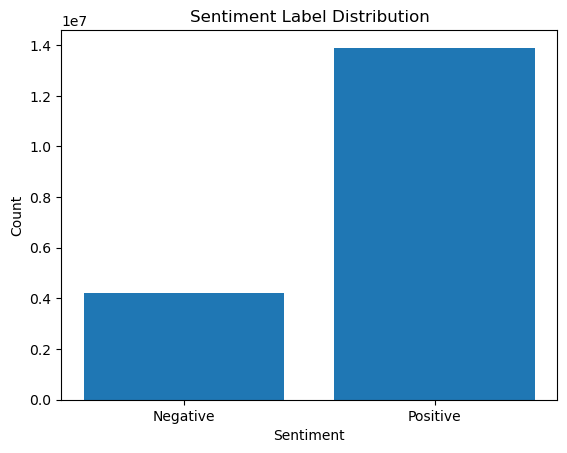

In [25]:
label_dist = processed_df.groupBy("label").count().orderBy("label").toPandas()
plt.bar(label_dist["label"], label_dist["count"], tick_label=["Negative", "Positive"])
plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

There are significantly more positive reviews than negative ones, indicating an imbalanced sentiment distribution. For now we’re keeping the dataset as is without any balancing but we'll decide on further adjustments during model training or based on baseline model performance.

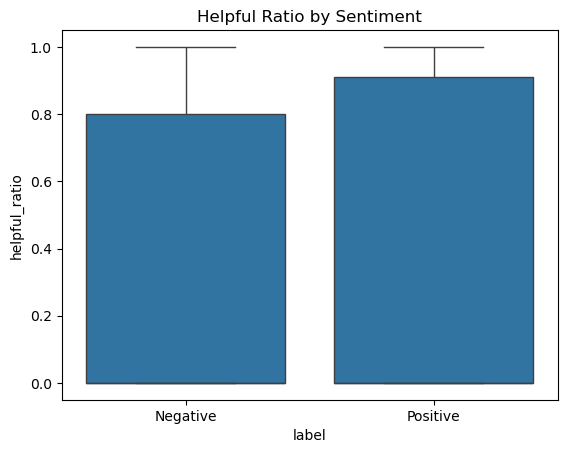

In [26]:
helpful_ratio_stats = processed_df.select("label", "helpful_ratio").sample(fraction=0.1, seed=42).toPandas()

sns.boxplot(data=helpful_ratio_stats, x="label", y="helpful_ratio")
plt.xticks([0, 1], ["Negative", "Positive"])
plt.title("Helpful Ratio by Sentiment")
plt.show()

Positive reviews tend to have a slightly higher helpfulness ratio compared to negative ones

In [27]:
# Group by category and label count
processed_df.groupBy("product_category", "label").count().orderBy("product_category", "label").show(50)

+------------------+-----+-------+
|  product_category|label|  count|
+------------------+-----+-------+
|           Apparel|    0|1437872|
|           Apparel|    1|4463908|
|            Beauty|    0|1118983|
|            Beauty|    1|3994742|
|             Books|    0| 654520|
|             Books|    1|2450960|
|       Electronics|    0| 775697|
|       Electronics|    1|2317251|
|         Furniture|    0| 190696|
|         Furniture|    1| 601281|
|Mobile_Electronics|    0|  34625|
|Mobile_Electronics|    1|  70315|
+------------------+-----+-------+



Across all product categories, positive reviews outnumber negative ones, with the largest volume seen in categories like Apparel, Beauty, and Electronics

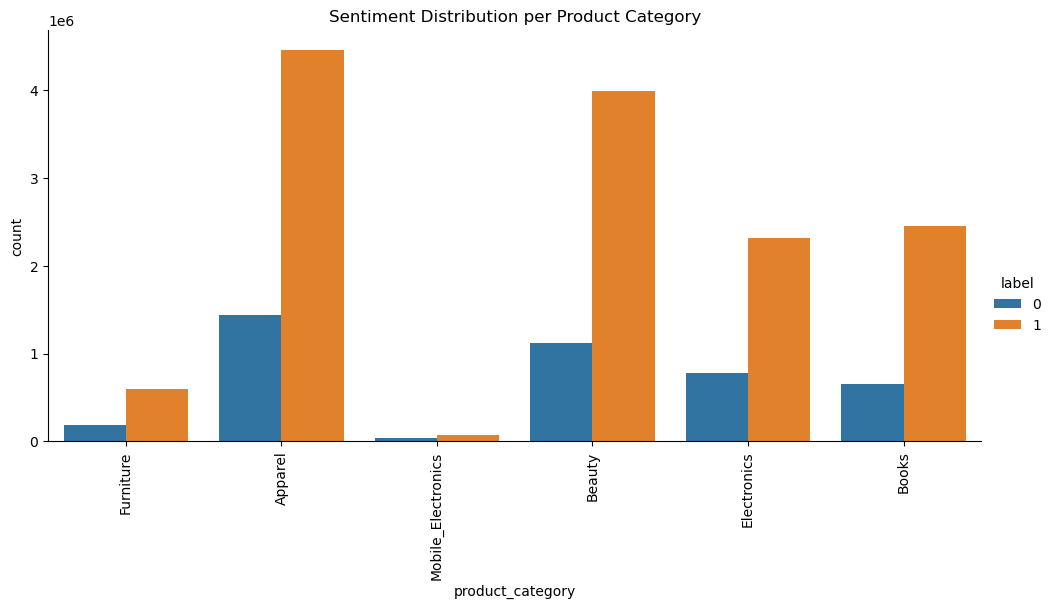

In [28]:
category_dist = processed_df.groupBy("product_category", "label").count().toPandas()

sns.catplot(
    data=category_dist, 
    x="product_category", y="count", hue="label", 
    kind="bar", height=5, aspect=2
)
plt.xticks(rotation=90)
plt.title("Sentiment Distribution per Product Category")
plt.show()

Positive reviews (label 1) consistently outnumber negative ones (label 0) across all product categories, with Apparel and Beauty having the highest overall review volumes

In [29]:
# sanity check - if any null values snuck in accidentally
processed_df.filter(col("label").isNull()).count()

0

Raw Features Used:
* star_rating (used to derive sentiment label)
* review_headline, review_body (combined for text analysis)
* product_category (categorical)
* vine, verified_purchase (binary indicators)
* helpful_votes, total_votes (used to compute helpfulness)
* review_date (used to derive date features)

Derived Features Implemented:
* label: sentiment (0 = negative, 1 = positive)
* combined_review_text: headline + body
* helpful_ratio: helpful_votes / total_votes
* has_votes: binary flag for voted reviews
* vine_binary, verified_purchase_binary: encoded binary flags
* product_category_vec: one-hot encoded category
* review_year, review_month, review_dayofweek: from review_date
* features: tokenized and vectorized text (via TF/TF-IDF)

In [30]:
processed_df.columns

['marketplace',
 'customer_id',
 'review_id',
 'product_id',
 'product_parent',
 'product_title',
 'product_category',
 'star_rating',
 'helpful_votes',
 'total_votes',
 'vine',
 'verified_purchase',
 'review_headline',
 'review_body',
 'review_date',
 'helpful_ratio',
 'has_votes',
 'review_length',
 'combined_review_text',
 'combined_text_length',
 'has_meaningful_content',
 'vine_binary',
 'verified_purchase_binary',
 'product_category_index',
 'product_category_vec',
 'review_year',
 'review_month',
 'review_dayofweek',
 'words',
 'filtered_words',
 'features',
 'label']

In [ ]:
columns_to_drop = [
    "marketplace", "customer_id", "review_id", "product_id", "product_parent",
    "product_title", "review_headline", "review_body", "review_date",
    "vine", "verified_purchase",  # original categorical strings
    "product_category",           # already encoded
    "product_category_index",     # only needed for encoding
    "review_length",              # similar to combined_text_length
    "combined_text_length",       # not very predictive
    "has_meaningful_content",     # already filtered out short ones
    "words", "filtered_words",    # intermediate columns
    "star_rating",                 # already created labels
    "helpful_votes", "total_votes",
    "combined_review_text"
]

In [ ]:
final_df = processed_df.drop(*columns_to_drop)
final_df.printSchema()

root
 |-- helpful_ratio: double (nullable = false)
 |-- has_votes: integer (nullable = false)
 |-- vine_binary: integer (nullable = false)
 |-- verified_purchase_binary: integer (nullable = false)
 |-- product_category_vec: vector (nullable = true)
 |-- review_year: integer (nullable = true)
 |-- review_month: integer (nullable = true)
 |-- review_dayofweek: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = false)



In [ ]:
# Save the dataset for training/testing
final_df.coalesce(8).write.mode("overwrite").parquet("gs://final-project-bucket-amazon/processed/final_dataset.parquet")

No dimensionality reduction was needed in this case. The model uses L1 regularization (LASSO) (this is in the Review Sentiment Modeling notebook), which already helps reduce unnecessary features, and the TF-IDF vector size was controlled using HashingTF.

In [34]:
spark.stop()